In [5]:
import math
from typing import Dict, List, Optional, Tuple
from lifelines.utils import concordance_index
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test


DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

MODEL_SCORE_GROUP_COLORS = {
    "Low": "#0072B2",   # Okabe-Ito blue
    "High": "#D55E00",  # Okabe-Ito vermillion
}


def _get_model_scores_binary_split(
    reg_df: pd.DataFrame,
    model,
    features: List[str],
) -> Tuple[pd.Index, pd.Index, float]:
    from sklearn.base import clone

    if "outcome" not in reg_df.columns:
        raise ValueError("reg_df must contain an 'outcome' column.")

    X = reg_df[features].drop(columns=["outcome"])
    y = reg_df["outcome"]

    mdl = clone(model)
    mdl.fit(X, y)

    if hasattr(mdl, "predict_proba"):
        scores = mdl.predict_proba(X)[:, 1]
    else:
        scores = mdl.decision_function(X)

    scores = pd.Series(scores, index=reg_df.index)
    med = float(scores.median())

    high_idx = scores[scores >= med].index
    low_idx = scores[scores < med].index
    return low_idx, high_idx, med


def plot_modelscore_survival_grid(
    fullProcessedData: Dict[str, Dict[str, pd.DataFrame]],
    cohort: str,
    survival_col: str,
    event_col: str,
    features: List[str],
    model,
    datasets: Optional[List[str]] = None,
    ncols: int = 3,  # không dùng trong layout 2x4, giữ để tương thích
    figsize: Optional[Tuple[float, float]] = (18, 6),
    title_prefix: str = "Model-score survival",
    dataset_colors: Optional[Dict[str, str]] = None,
    group_colors: Optional[Dict[str, str]] = None,
    show_censors: bool = False,
    ci_show: bool = False,
    dataset_strip_height: float = 0.02,
    dataset_strip_y: float = 1.01,
    font_scale: float = 1.0,
    convert_to_months: bool = True,  # NEW parameter
    days_per_month: float = 30.0,    # NEW parameter
) -> Tuple[plt.Figure, pd.DataFrame]:
    """
    Plot KM curves using model-score median split with fixed 2x4 layout:
        - Column 0 (both rows merged): Origin (large plot)
        - Columns 1–3 (2 rows each): synthetic datasets (up to 6)
    
    Args:
        convert_to_months: If True, convert survival time from days to months
        days_per_month: Number of days per month for conversion (default: 30.0)
    """
    # ------------------- Dataset list & ordering -------------------
    if datasets is None:
        dataset_names = list(fullProcessedData.keys())
    else:
        dataset_names = datasets

    dataset_colors = dataset_colors or DATASET_COLORS
    group_colors = group_colors or MODEL_SCORE_GROUP_COLORS

    # Đảm bảo Origin đứng đầu
    if "Origin" not in dataset_names:
        raise ValueError("This layout requires a dataset named 'Origin' in datasets.")
    dataset_names = ["Origin"] + [d for d in dataset_names if d != "Origin"]

    # Giới hạn tối đa 7 dataset (1 Origin + 6 synthetic)
    if len(dataset_names) > 7:
        dataset_names = dataset_names[:7]

    n_datasets = len(dataset_names)
    synthetic_names = dataset_names[1:]  # bỏ Origin
    max_small_axes = 6  # 2 hàng × 3 cột bên phải

    # ------------------- Global style -------------------
    plt.rcParams.update(
        {
            "font.size": 10 * font_scale,
            "axes.titlesize": 11 * font_scale,
            "axes.labelsize": 10 * font_scale,
            "legend.fontsize": 9 * font_scale,
            "xtick.labelsize": 9 * font_scale,
            "ytick.labelsize": 9 * font_scale,
            "axes.linewidth": 1.0,
        }
    )

    if figsize is None:
        figsize = (18, 6)

    fig = plt.figure(figsize=figsize)

    # Layout 2×4 với width_ratios cho Origin hẹp hơn một chút
    gs = gridspec.GridSpec(
        2,
        4,
        figure=fig,
        wspace=0.1,
        hspace=0.3,
        width_ratios=[2, 1.25, 1.25, 1.25],
        height_ratios=[1, 1])

    # Ax lớn cho Origin: chiếm cả 2 hàng cột 0
    ax_origin = fig.add_subplot(gs[:, 0])
    ax_origin.set_box_aspect(1.0)  # tỉ lệ khung hình gần vuông, giống layout PBRM1

    # 6 panel nhỏ: row=0..1, col=1..3
    axes_small: List[plt.Axes] = []
    for r in range(2):
        for c in range(1, 4):
            ax = fig.add_subplot(gs[r, c])
            # ax.set_box_aspect(1.0)
            axes_small.append(ax)
    # nếu synthetic < 6, một số axes_small sẽ bị tắt sau

    summary_rows = []
    color_low = group_colors.get("Low", "#0072B2")
    color_high = group_colors.get("High", "#D55E00")

    kmf = KaplanMeierFitter()

    # Determine time unit label
    time_unit = "months" if convert_to_months else "days"

    # ------------------- helper: vẽ một dataset -------------------
    def _plot_single_dataset(ds_name: str, ax: plt.Axes, is_large: bool = False) -> None:
        nonlocal summary_rows

        if ds_name not in fullProcessedData:
            ax.axis("off")
            return
        if cohort not in fullProcessedData[ds_name]:
            raise ValueError(f"cohort '{cohort}' not found for dataset '{ds_name}'.")

        reg_df = fullProcessedData[ds_name][cohort].copy()

        if survival_col not in reg_df.columns or event_col not in reg_df.columns:
            raise ValueError(
                f"Dataset '{ds_name}' / cohort '{cohort}' must contain columns "
                f"'{survival_col}' and '{event_col}' to plot KM."
            )

        # Split by model score (median)
        low_idx, high_idx, med = _get_model_scores_binary_split(
            reg_df=reg_df, model=model, features=features
        )

        df_low = reg_df.loc[low_idx].copy()
        df_high = reg_df.loc[high_idx].copy()

        # Coerce types
        reg_df[survival_col] = pd.to_numeric(reg_df[survival_col], errors="coerce")
        reg_df[event_col] = pd.to_numeric(reg_df[event_col], errors="coerce").fillna(0).astype(int)

        # ========== CONVERT TO MONTHS IF REQUESTED ==========
        if convert_to_months:
            df_low[survival_col] = df_low[survival_col] / days_per_month
            df_high[survival_col] = df_high[survival_col] / days_per_month
            reg_df[survival_col] = reg_df[survival_col] / days_per_month
        # ====================================================

        # Dataset strip
        ds_color = dataset_colors.get(ds_name, "#cccccc")
        ax.add_patch(
            plt.Rectangle(
                (0, dataset_strip_y),
                1,
                dataset_strip_height,
                transform=ax.transAxes,
                facecolor=ds_color,
                edgecolor="none",
                clip_on=False,
                zorder=10,
            )
        )

        def _plot_group(g: pd.DataFrame, label: str, color: str) -> None:
            g2 = g.dropna(subset=[survival_col, event_col]).copy()
            if len(g2) == 0:
                return
            kmf.fit(g2[survival_col], event_observed=g2[event_col], label=label)
            kmf.plot_survival_function(
                ax=ax,
                ci_show=ci_show,
                show_censors=show_censors,
                color=color,
                linewidth=2.0 if is_large else 1.8,
                censor_styles={"ms": 4, "marker": "|", "mew": 1.2} if show_censors else None,
            )

        _plot_group(df_low, label=f"Low score (n={len(df_low)})", color=color_low)
        _plot_group(df_high, label=f"High score (n={len(df_high)})", color=color_high)

        # Log-rank p-value
        pvalue = np.nan
        try:
            gL = df_low.dropna(subset=[survival_col, event_col]).copy()
            gH = df_high.dropna(subset=[survival_col, event_col]).copy()
            if len(gL) > 0 and len(gH) > 0:
                res = logrank_test(
                    gL[survival_col],
                    gH[survival_col],
                    event_observed_A=gL[event_col],
                    event_observed_B=gH[event_col],
                )
                pvalue = float(res.p_value)
        except Exception:
            pvalue = np.nan

        # C-index: mã hóa Low=0, High=1, dùng concordance_index
        cindex_text = "NA"
        try:
            df_cindex = pd.concat(
                [df_low.assign(group_binary=1), df_high.assign(group_binary=0)],
                axis=0,
            )
            df_cindex = df_cindex.dropna(subset=[survival_col, event_col, "group_binary"]).copy()
            if len(df_cindex) > 0 and df_cindex["group_binary"].nunique() > 1 and df_cindex[event_col].sum() > 0:
                cindex = concordance_index(
                    df_cindex[survival_col],
                    df_cindex["group_binary"],   # risk score: nhóm High (1) kỳ vọng risk cao hơn
                    df_cindex[event_col],
                )
                cindex_text = f"{cindex:.3f}"
            else:
                cindex_text = "insufficient events"
        except Exception:
            cindex_text = "fit error"
        
        ptext = "p = NA" if np.isnan(pvalue) else f"p = {pvalue:.4g}"
        ax.text(
            0.98,
            0.96,
            ptext,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10 * font_scale,
            zorder=10,
        )

        ax.text(
            0.98,
            0.88,
            f"C-index: {cindex_text}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10 * font_scale,
            zorder=10,
        )

        # Legend 
        ax.legend(
            loc="lower left",
            bbox_to_anchor=(0, 0.005),
            frameon=False,
            framealpha=0.0,
            borderaxespad=0.1,
        )

        ax.set_title(f"{title_prefix} — {ds_name}", fontweight="bold", pad=12)
        # Update xlabel to show correct unit
        ax.set_xlabel(f"Time ({survival_col})")
        ax.set_ylim(0, 1.02)
        ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

        # chỉ Origin giữ label trục y để bảng gọn hơn
        if is_large:
            ax.set_ylabel("Survival probability")
        else:
            ax.set_ylabel("")

        summary_rows.append(
            {
                "Dataset": ds_name,
                "logrank_p": (np.nan if np.isnan(pvalue) else float(pvalue)),
                "C-index": cindex_text,
                "n_low": int(len(df_low)),
                "n_high": int(len(df_high)),
                "median_score": float(med),
            }
        )

    # ------------------- Vẽ Origin -------------------
    _plot_single_dataset("Origin", ax_origin, is_large=True)

    # ------------------- Vẽ synthetic -------------------
    for i, ds_name in enumerate(synthetic_names):
        if i >= max_small_axes:
            break
        ax_small = axes_small[i]
        _plot_single_dataset(ds_name, ax_small, is_large=False)

    # Tắt axes thừa nếu synthetic < 6
    if len(synthetic_names) < max_small_axes:
        for j in range(len(synthetic_names), max_small_axes):
            axes_small[j].axis("off")

    plt.tight_layout()

    summary_df = pd.DataFrame(
        summary_rows,
        columns=["Dataset", "logrank_p", "C-index", "n_low", "n_high", "median_score"],
    )
    return fig, summary_df

In [7]:
import pandas as pd, numpy as np
from joblib import Parallel, delayed
from scipy.stats import wilcoxon
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Coloring (violin/survival)
DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

# ----------------------------------------------------
# Core utilities (giữ logic notebook)
def addColumns(data):
    responderCrit = data['BR'].isin(['CR','PR'])
    progressorCrit = data['BR'].isin(['PD'])
    data["PD_Responders"] = "SD/MR"
    data.loc[responderCrit,"PD_Responders"] = 'Responder'
    data.loc[progressorCrit,"PD_Responders"] = 'Progressor'
    data["PD_nonPD"] = 0
    data.loc[progressorCrit, "PD_nonPD"] = 1
    import math
    for col in ["nonsyn_muts","clonal_muts","subclonal_muts","total_neoantigens"]:
        data[f"log_{col}"] = [math.log((x if x>=0 else 0)+1e-9,10) for x in data[col]]
    return data

def GenRegDF(df, categVars, quantVars, outcome=None):
    if outcome is not None:
        regDF = df[df[outcome].apply(np.isreal) & ~df[outcome].isnull()][[outcome]+quantVars]
    else:
        regDF = df[quantVars]
    nullQuants = []
    for q in quantVars:
        regDF.loc[:, q] = pd.to_numeric(regDF[q], errors='coerce')
        if regDF[q].isnull().sum()>0: nullQuants.append(q)
        med = regDF[q].median()
        regDF[q+"_upper"] = (regDF[q] > med).astype(int)
        regDF[q+"_lower"] = (regDF[q] <= med).astype(int)
    for c in categVars:
        dummies = pd.get_dummies(df[c], prefix=c)
        regDF = regDF.merge(dummies.iloc[:,1:], left_index=True, right_index=True)
    scaler = MinMaxScaler((0,1))
    good = [c for c in regDF.columns if c not in nullQuants]
    temp = pd.DataFrame(scaler.fit_transform(regDF[good]), index=regDF.index, columns=good)
    temp[nullQuants] = regDF[nullQuants]
    regDF = temp
    regDF["intercept"] = 1
    return regDF

# ----------------------------------------------------
# Chuẩn bị dữ liệu (dataset_dict đã merge ssGSEA)
def build_full_processed(dataset_dict):
    out = {}
    for name, df in dataset_dict.items():
        dfp = addColumns(df.copy())
        dfp["LN_Met"] = dfp["LN_Met"].astype(int)
        out[name] = dfp
    return out

def make_reg_tables(processed):
    fullProcessedData = {}
    for name, fullDF in processed.items():
        quantVars = ['log_nonsyn_muts','heterogeneity','purity','ploidy','Tx_Start_LDH']
        categVars = ['LN_Met']
        postIpi = fullDF[fullDF["daysBiopsyAfterIpiStart"]=="postIpi"].index
        noIpi   = fullDF[fullDF["daysBiopsyAfterIpiStart"]=="noIpi"].index
        prog = list(fullDF[fullDF['PD_Responders']=="Progressor"].index)
        nprog= list(fullDF[fullDF['PD_nonPD']==0].index)
        PDpost = list(set(postIpi)&set(prog)); nPDpost = [x for x in postIpi if x not in prog]
        PDno   = list(set(noIpi)&set(prog));  nPDno   = [x for x in noIpi if x not in prog]

        regDFs = {}
        for outcome, (g1, g0) in {
            "Ipi_Exp": [PDpost, nPDpost],
            "Ipi_Naive": [PDno, nPDno],
        }.items():
            tmp = fullDF.copy()
            tmp.loc[[i for i in g1 if i in tmp.index], 'outcome'] = 1
            tmp.loc[[i for i in g0 if i in tmp.index], 'outcome'] = 0
            tmp = tmp[~tmp['outcome'].isnull()]
            regDFs[outcome] = tmp

        fullRegDFs = {}
        for outcome in ["Ipi_Exp","Ipi_Naive"]:
            regDF = regDFs[outcome]
            tempDF = GenRegDF(fullDF[categVars+quantVars], categVars, quantVars)
            regDF = regDF.merge(tempDF, how='inner', left_index=True, right_index=True)
            regDF = regDF.select_dtypes(include=[np.number])
            
            regDF = regDF.loc[:, regDF.var()!=0]
            regDF['intercept'] = 1
            fullRegDFs[outcome] = regDF
            
        fullProcessedData[name] = fullRegDFs
    return fullProcessedData

# ----------------------------------------------------
# Model-score survival (median split trên predict_proba)
def get_model_scores(regDF, model):
    X = regDF.drop(columns=['outcome'])
    y = regDF['outcome']
    mdl = clone(model)
    mdl.fit(X, y)
    if hasattr(mdl, "predict_proba"):
        scores = mdl.predict_proba(X)[:,1]
    else:
        scores = mdl.decision_function(X)
    return pd.Series(scores, index=regDF.index)

def km_logrank_from_scores(fullDF, scores, survival_col, event_col,
                           title="PFS", colors=("tab:blue","tab:orange")):
    med = scores.median()
    upper = scores[scores >= med].index  # High model score
    lower = scores[scores <  med].index  # Low model score
    groups = [lower, upper]
    labels = ['Low Model Score','High Model Score']
    kmfs = []
    fig, ax = plt.subplots(figsize=(8,5))
    for i, grp in enumerate(groups):
        kmf = KaplanMeierFitter()
        kmf.fit(fullDF.loc[grp, survival_col], fullDF.loc[grp, event_col],
                label=labels[i])
        kmf.plot(ax=ax, ci_show=False, linewidth=2.0, color=colors[i])
        kmfs.append(kmf)
        print(labels[i], "n =", len(grp))
    # log-rank
    all_idx = list(lower) + list(upper)
    lbls = ['low']*len(lower) + ['high']*len(upper)
    lr = logrank_test(fullDF.loc[all_idx, survival_col],
                      fullDF.loc[all_idx, survival_col],
                      event_observed_A=fullDF.loc[all_idx, event_col],
                      event_observed_B=fullDF.loc[all_idx, event_col],
                      groups=lbls) if False else logrank_test(
                        fullDF.loc[lower, survival_col], fullDF.loc[upper, survival_col],
                        event_observed_A=fullDF.loc[lower, event_col],
                        event_observed_B=fullDF.loc[upper, event_col]
                      )
    ax.set_xlabel("Time"); ax.set_ylabel("Survival probability")
    ax.set_title(f"{title} (log-rank p={lr.p_value:.3g})")
    plt.tight_layout()
    return {"median": med, "logrank_p": lr.p_value, "fig": fig, "ax": ax,
            "upper_n": len(upper), "lower_n": len(lower)}

def run_modelscore_survival(fullProcessedData, cohort="Ipi_Exp",
                            survival_col="PFS", event_col="progressed",
                            model_name="Logistic_Regression",
                            use_dataset="Origin",
                            features=None):
    fullDF_raw = fullProcessedData[use_dataset][cohort].copy()
    if features is None:
        # dùng toàn bộ regDF (hallmark + clin) đã tạo
        regDF = fullProcessedData[use_dataset][cohort]
        
    else:
        regDF = fullProcessedData[use_dataset][cohort][features + ['outcome']]

    model_bank = {
        "Logistic_Regression": LogisticRegression(penalty='l2', max_iter=100000,
                                                 random_state=42, solver='lbfgs', n_jobs=-1),
        "MLP": MLPClassifier(alpha=0.01, max_iter=10000, validation_fraction=0.1,
                             random_state=42, hidden_layer_sizes=150),
    }
    model = model_bank[model_name]

    scores = get_model_scores(regDF, model)
    # fullDF gốc để lấy thời gian/sự kiện
    # fullDF_raw = regDF  # regDF giữ cùng index; ta cần cột survival/event từ dataset gốc
    return km_logrank_from_scores(fullDF_raw, scores,
                                  survival_col=survival_col,
                                  event_col=event_col,
                                  title=f"{cohort} {survival_col} by {model_name} score")

/tmp/ipykernel_874973/1799565607.py:335: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Successfully saved PFS for seed 3


/tmp/ipykernel_874973/1799565607.py:335: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Successfully saved OS for seed 3


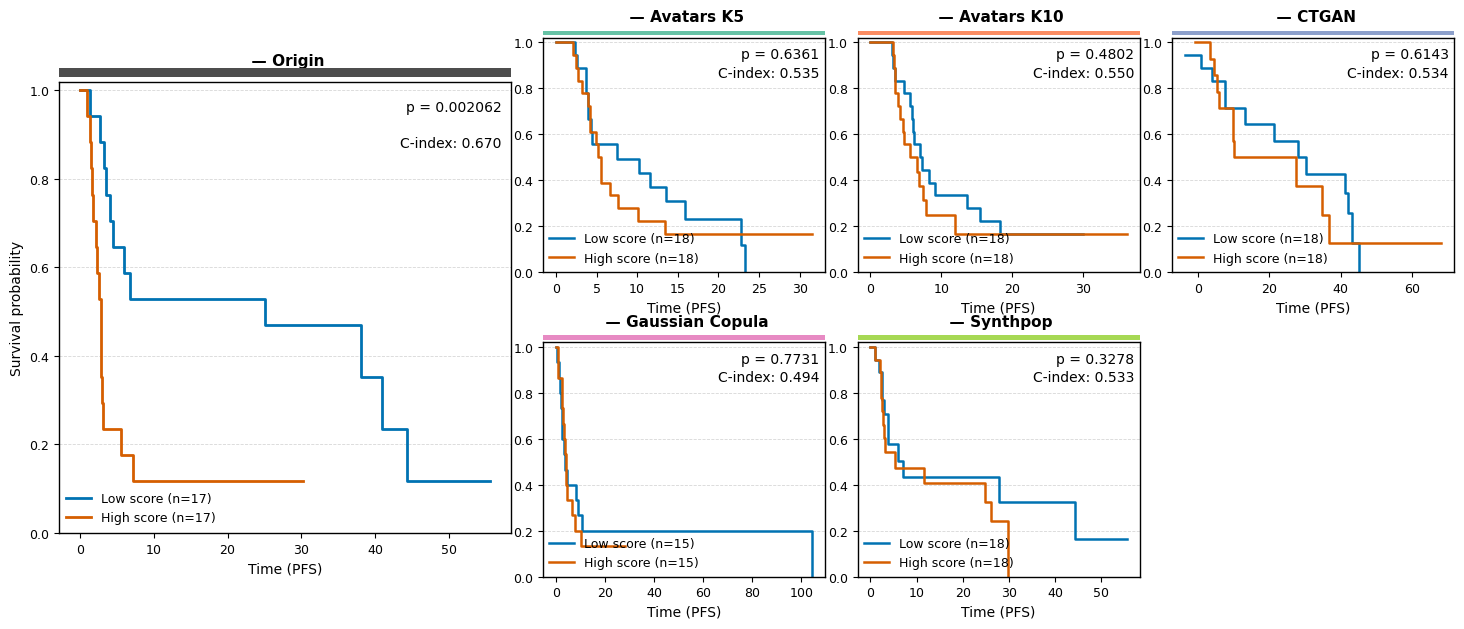

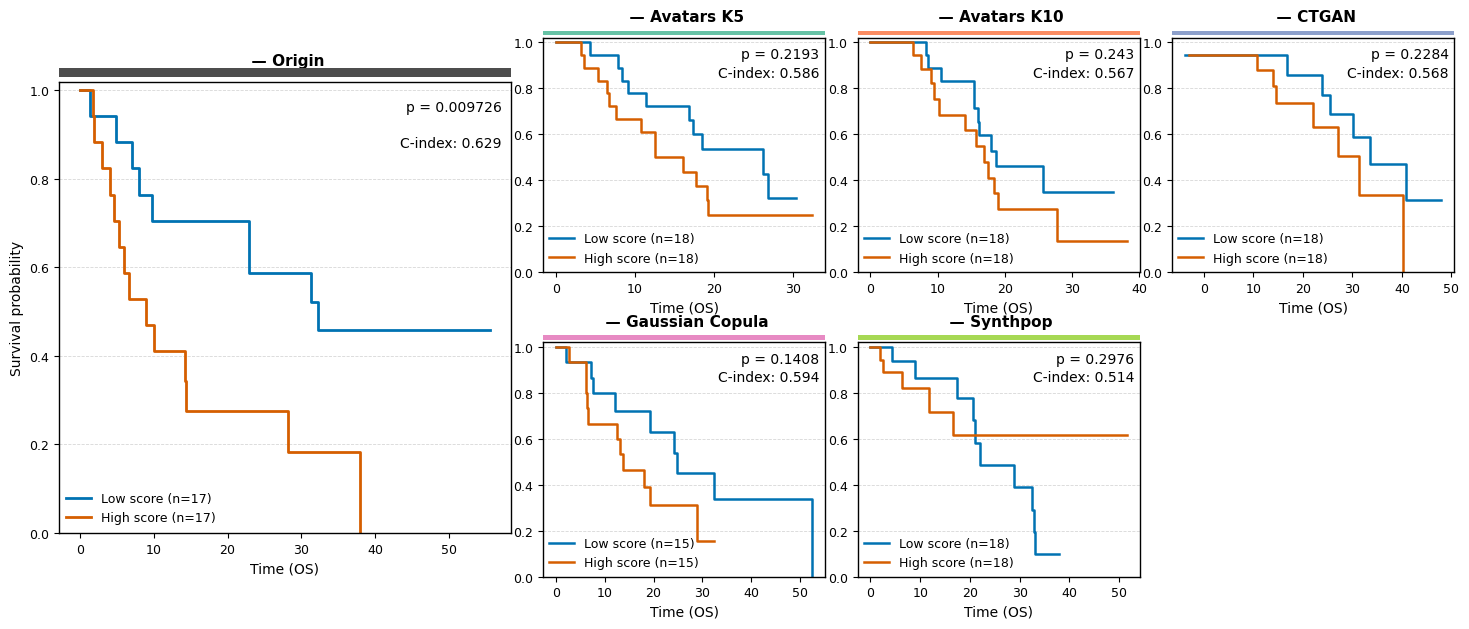

In [19]:
from sklearn.linear_model import LogisticRegression

# seeds = [0,1,2,3,42]
seeds = [3]
for seed in seeds:
# seed = 42
    names = ['Origin','Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop']
    datasets = ['original_data', f'avatarsk5_{seed}', f'avatarsk10_{seed}', f'ctgan_{seed}', f'gaussiancopula_{seed}', f'synthpop_{seed}']
    
    dataset_dict = {}
    
    for i, dataset in enumerate(datasets):
        data = pd.read_csv(f'../Melanoma/Data/{dataset}.csv', index_col = 0)
        ssgsea = pd.read_csv(f'../Melanoma/NarrowUtility/ssGSEA/MHC/{dataset}.csv', index_col = 0)
    
        df_merged = pd.concat([data, ssgsea], axis = 1)
        dataset_dict[names[i]]=df_merged
    # ["Origin","Avatars K5","Avatars K10","CTGAN","Gaussian Copula","Synthpop","TVAE"]
    processed = build_full_processed(dataset_dict)
    fullProcessedData = make_reg_tables(processed)
    model = LogisticRegression(
        penalty="l2", max_iter=100000, random_state=42, solver="lbfgs", n_jobs=-1
    )
    features = ['MHC-II', 'LN_Met_1', 'Tx_Start_LDH_lower', 'outcome']
    try:
        fig_pfs, summary_pfs = plot_modelscore_survival_grid(
            fullProcessedData=fullProcessedData,
            cohort="Ipi_Exp",
            survival_col="PFS",
            event_col="progressed",
            features=features,
            model=model,
            figsize=(18,7),
            datasets=names, # Sử dụng list names đã định nghĩa ở trên
            title_prefix="",
        )
        fig_pfs.savefig(f"SA_Ipi/LR_{seed}_PFS.pdf", dpi=300, bbox_inches="tight")
        print(f"Successfully saved PFS for seed {seed}")
    except Exception as err:
        print(f"Error in PFS for seed {seed}: {err}")

    # --- Xử lý cho OS ---
    try:
        fig_os, summary_os = plot_modelscore_survival_grid(
            fullProcessedData=fullProcessedData,
            cohort="Ipi_Exp",
            survival_col="OS",
            event_col="dead",
            features=features,
            model=model,
            figsize=(18,7),
            datasets=names,
            title_prefix="",
        )
        fig_os.savefig(f"SA_Ipi/LR_{seed}_OS.pdf", dpi=300, bbox_inches="tight")
        print(f"Successfully saved OS for seed {seed}")
    except Exception as err:
        print(f"Error in OS for seed {seed}: {err}")

    plt.show()